Building a function to perform the suzuki-trotter method, so able to explore different time steps, etc easily.

In [15]:
import qiskit
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.compiler import transpile
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumRegister, AncillaRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import json
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import functools as ft

In [16]:
from qiskit.primitives import StatevectorEstimator

In [17]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter


In [18]:
import Hamiltonian as hm

In [19]:
L=4
Jz=1.1
hamiltonian = hm.hamiltonian1(L,Jz)

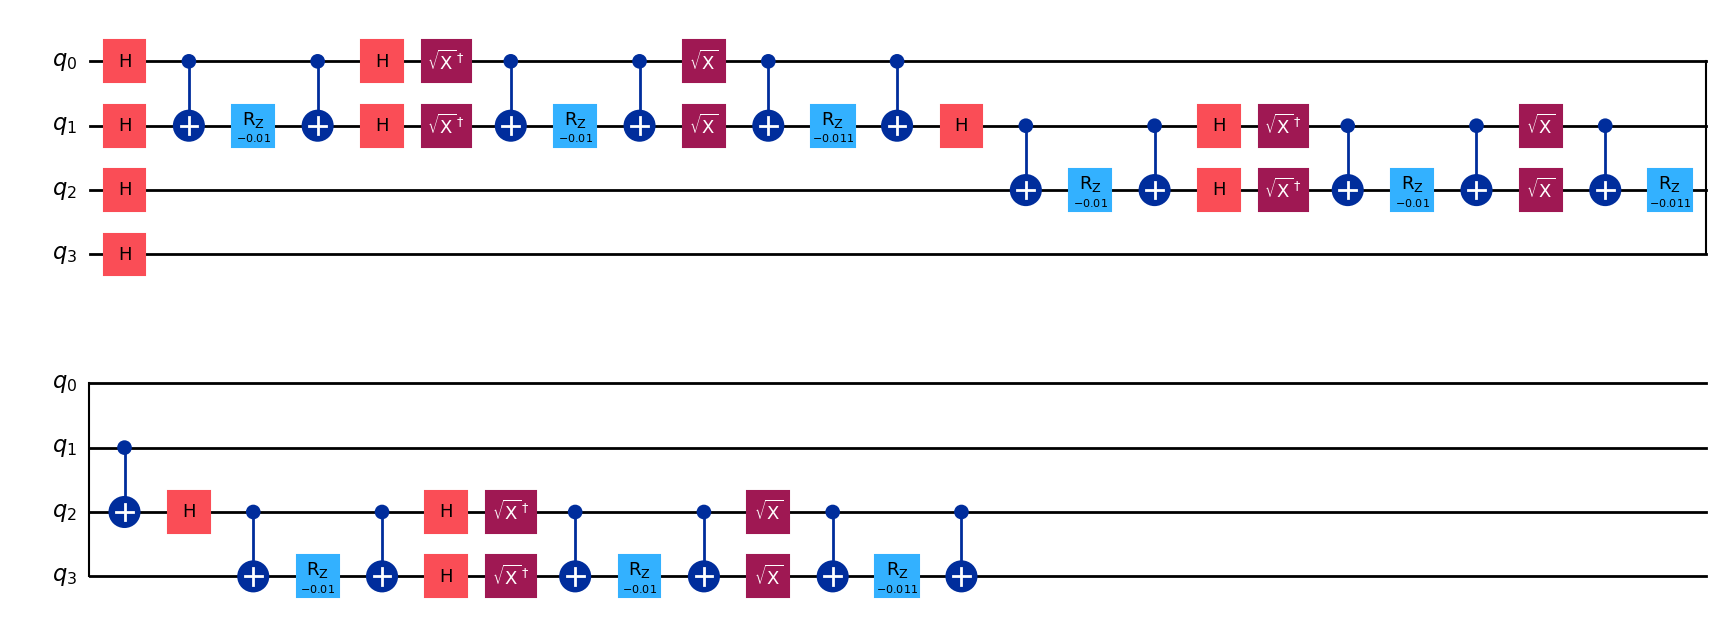

In [20]:
dt = 0.5 * 1e-2
gate = PauliEvolutionGate(dt * hamiltonian)

st = SuzukiTrotter(order=1, reps=1)   #whats the advantage of doing reps here vs. appending on then measuring? I guess can only measure every reps?
# in real life, fix circuit depth/trotter circuit, then change dt to get data for different times
circ = st.synthesize(gate)

circ.decompose().draw("mpl")

Okay actually running it and measuring

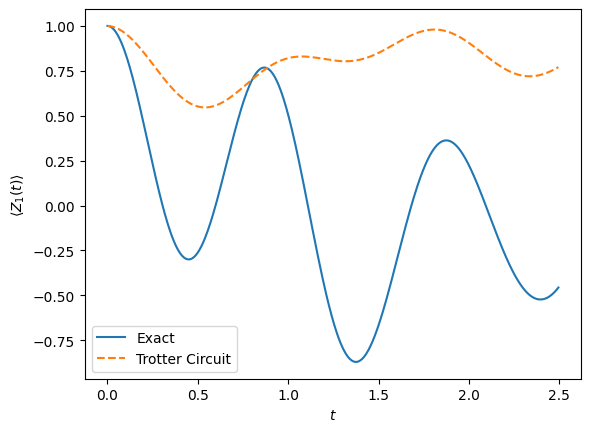

In [27]:
# Define the 'Estimator' primitive used to measure/estimate expectation values of observables
estimator = StatevectorEstimator()

# Define the observable we wish to estimate
z_obs = SparsePauliOp(["ZIII"],coeffs=[1])  #just Z_1 for now

# Initialise circuit
qc = QuantumCircuit(int(L))
all0, all1 = hm.initialise(Jz,L)[1] #this format only works for J_z > 1 because spits out two in a list
qc.initialize(all0)
#apply rotation
middle = L //2 #picks L/2 int value
qc.ry(np.pi/2, middle) #rotation here is into x-y plane
initial = Statevector(qc)  #initial state, now rotated

# Define a single Suzuki-Trotter timestep
st = SuzukiTrotter(order=1, reps=1)
circ = st.synthesize(gate)

# Prepare an empty list to store data and run a loop over timesteps
zlist2 = []
for t in range(300):
    qc.append(circ,[0,1,2,3])
    pub = (qc, [z_obs])
    result = estimator.run(pubs=[pub]).result()
    z_result = result[0].data.evs[0]
    zlist2 += [z_result]

# Plot results

t_tot = dt*300
numsteps = 300
tlist,zlist = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist, zlist, label = 'Exact')
plt.plot(tlist, zlist2, '--', label = 'Trotter Circuit')
plt.ylabel(r'$\langle Z_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

Hmm this is not good $\uparrow$, why are the measuremtents so close to 1, not ever going close to -1

okay, build a function that does this, but keeps trotter circuit the same (ex. 5 reps), and changes dt to get diffeernt results